Shape: (1079, 1182)


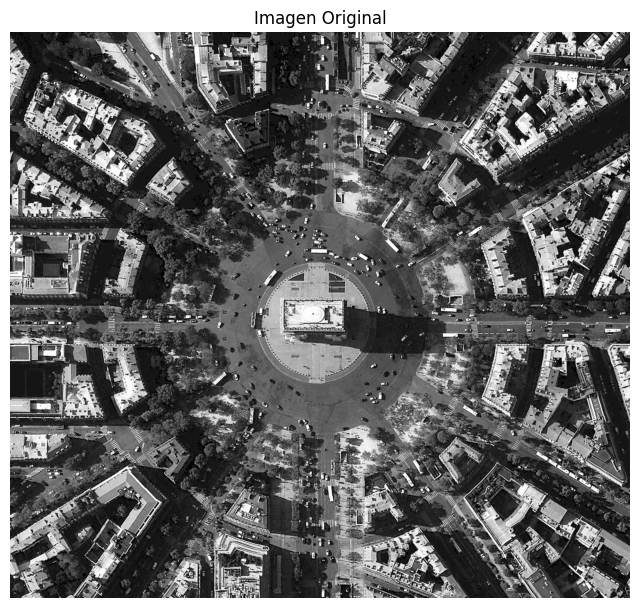

In [98]:
# ============================================================
# Taller Reconstrucción 3D Estéreo Satelital OpenCV
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1. Cargar imagen original
# ------------------------------------------------------------

img = cv2.imread("base_image.png", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception("No se encontró la imagen")

print("Shape:", img.shape)

plt.figure(figsize=(8,8))
plt.imshow(img, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")
plt.show()

(1079, 1180)
(1079, 1180)


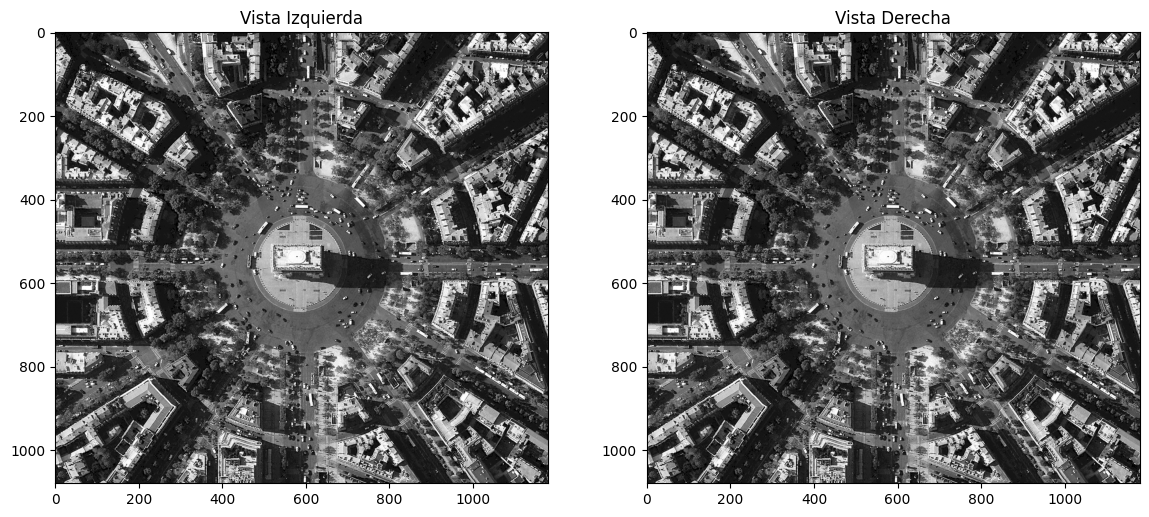

In [99]:
# ------------------------------------------------------------
# 2. Crear par estéreo artificial
# ------------------------------------------------------------

shift = 2

imgL = img[:, :-shift]
imgR = img[:, shift:]

print(imgL.shape)
print(imgR.shape)

fig, ax = plt.subplots(1,2, figsize=(14,6))

ax[0].imshow(imgL, cmap="gray")
ax[0].set_title("Vista Izquierda")

ax[1].imshow(imgR, cmap="gray")
ax[1].set_title("Vista Derecha")

plt.show()

In [100]:
# ------------------------------------------------------------
# 3. Calcular disparidad
# ------------------------------------------------------------

stereo = cv2.StereoBM_create(
    numDisparities=64,
    blockSize=15
)

disparity = stereo.compute(imgL, imgR).astype(np.float32) / 16.0

print("Min:", disparity.min())
print("Max:", disparity.max())

Min: -1.0
Max: 2.4375


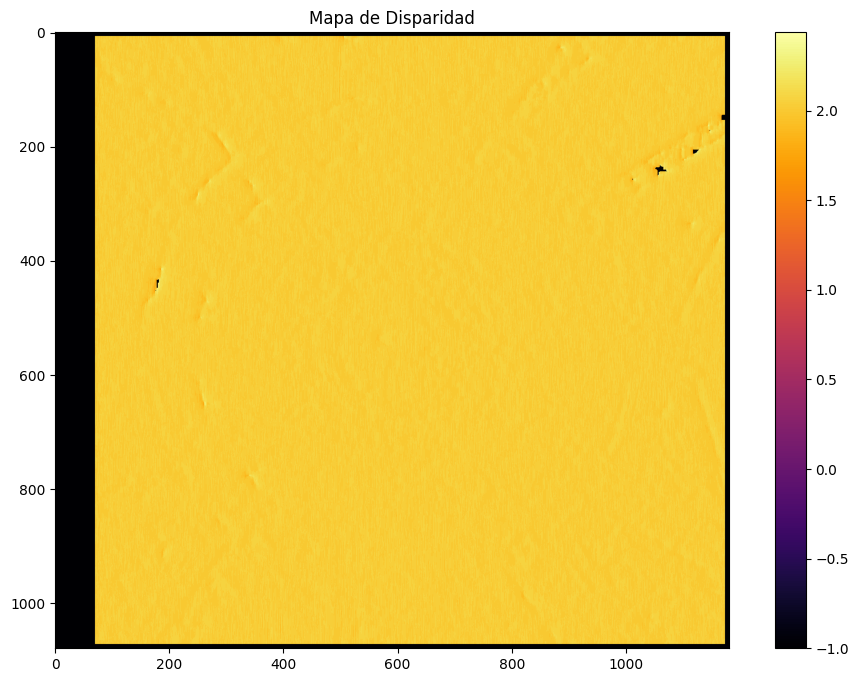

In [101]:
# ------------------------------------------------------------
# 4. Visualizar mapa de disparidad
# ------------------------------------------------------------

plt.figure(figsize=(12,8))

plt.imshow(disparity, cmap="inferno")
plt.colorbar()
plt.title("Mapa de Disparidad")

plt.show()

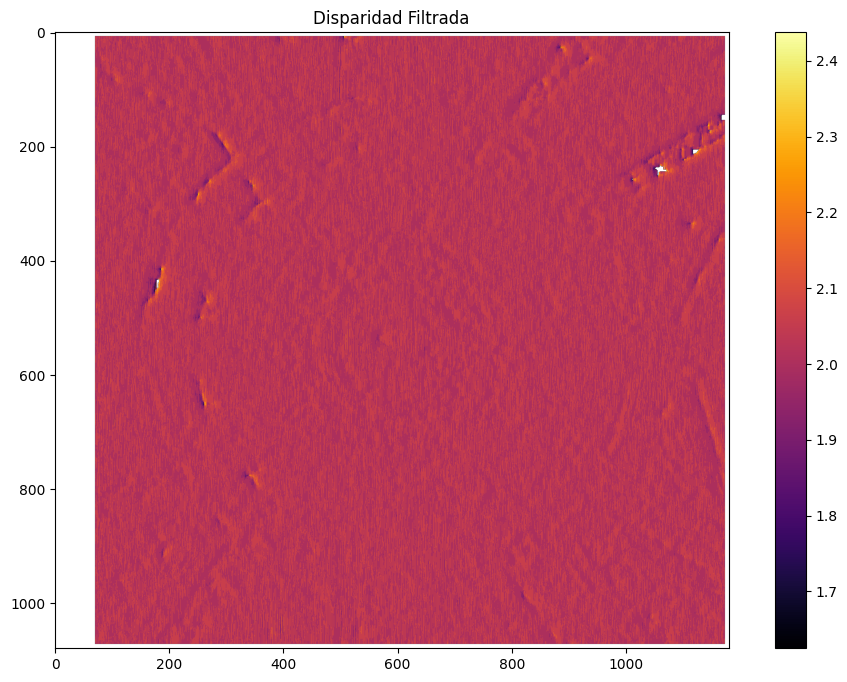

In [102]:
# ------------------------------------------------------------
# 5. Limpiar valores inválidos
# ------------------------------------------------------------

disp = disparity.copy()

disp[disp <= 0] = np.nan

plt.figure(figsize=(12,8))

plt.imshow(disp, cmap="inferno")
plt.colorbar()
plt.title("Disparidad Filtrada")

plt.show()

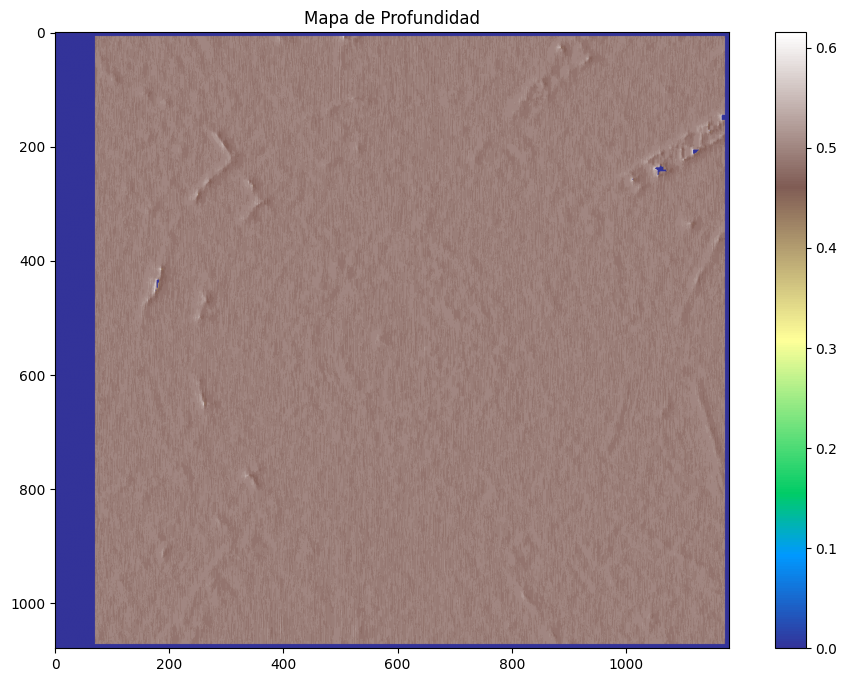

In [103]:
# ------------------------------------------------------------
# 6. Generar mapa de profundidad
# ------------------------------------------------------------

depth_map = 1.0 / (disp + 1e-6)

depth_map = np.nan_to_num(depth_map)

depth_map = np.clip(depth_map, 0, 100)

plt.figure(figsize=(12,8))

plt.imshow(depth_map, cmap="terrain")
plt.colorbar()
plt.title("Mapa de Profundidad")

plt.show()

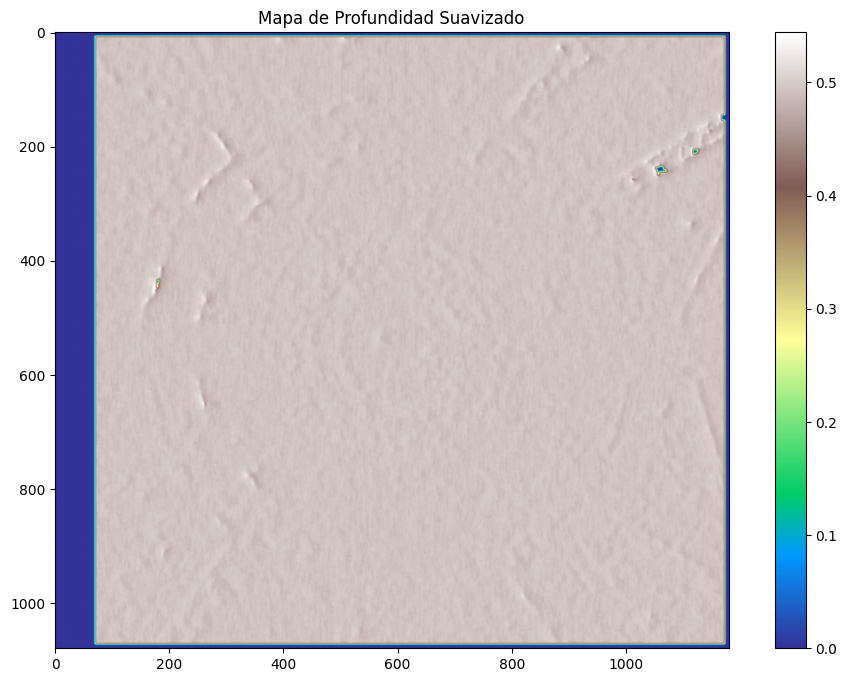

In [104]:
# ------------------------------------------------------------
# 7. Suavizado para mejor visualización 3D
# ------------------------------------------------------------

depth_map = cv2.GaussianBlur(depth_map, (7,7), 0)

plt.figure(figsize=(12,8))

plt.imshow(depth_map, cmap="terrain")
plt.colorbar()
plt.title("Mapa de Profundidad Suavizado")

plt.show()

In [105]:
# ------------------------------------------------------------
# 8. Reducir tamaño para render 3D
# ------------------------------------------------------------

factor = 4

depth_small = depth_map[::factor, ::factor]
texture_small = imgL[::factor, ::factor]

print(depth_small.shape)

(270, 295)


In [106]:
# ------------------------------------------------------------
# 9. Crear malla 3D
# ------------------------------------------------------------

rows, cols = depth_small.shape

x, y = np.meshgrid(
    np.arange(cols),
    np.arange(rows)
)

fig = go.Figure(
    data=[
        go.Surface(
            z=depth_small,
            surfacecolor=texture_small,
            colorscale="Gray",
            showscale=False
        )
    ]
)

fig.update_layout(
    title="Reconstrucción 3D del Terreno",
    autosize=True,
    width=1000,
    height=800
)

fig.show()